# 03 — Stage B: classifier (sklearn + LightGBM)

Train on Stage A high+medium confidence labels, predict on all campaigns.
Use GroupKFold by `customer_id` to avoid leakage (same client's campaigns
share naming style and audience preferences).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, roc_auc_score,
                             confusion_matrix, ConfusionMatrixDisplay)
import lightgbm as lgb

sns.set_style("whitegrid")
RANDOM_STATE = 0


## Load Stage A labels + raw metrics

In [2]:
raw = pd.read_csv("campaigns_unlabeled.csv")
stage_a = pd.read_csv("campaigns_stage_a.csv")
print("stage_a:", stage_a.shape)
print(stage_a.confidence.value_counts())
print(stage_a.funnel_label.value_counts(dropna=False))


stage_a: (637, 14)
high      338
medium    202
low        97
Name: confidence, dtype: int64
top       297
bottom    287
NaN        53
Name: funnel_label, dtype: int64


In [3]:
# Aggregate raw metrics to campaign level
metric_agg = raw.groupby("campaign_id").agg(
    n_months=("month", "nunique"),
    impressions=("impressions", "sum"),
    clicks=("clicks", "sum"),
    conversions=("conversions", "sum"),
    spend=("spend_usd", "sum"),
    mean_ctr=("ctr", "mean"),
    mean_cpm=("cpm_usd", "mean"),
    mean_cpc=("cpc_usd", "mean"),
    mean_conv_rate=("conversion_rate", "mean"),
    mean_roas=("roas", "mean"),
    roas_null_share=("roas", lambda s: s.isna().mean()),
).reset_index()

# Recompute aggregate rates from totals (cleaner than mean-of-rates)
metric_agg["agg_ctr"] = metric_agg.clicks / metric_agg.impressions.replace(0, np.nan)
metric_agg["agg_conv_rate"] = metric_agg.conversions / metric_agg.clicks.replace(0, np.nan)
metric_agg["agg_cpm"] = 1000 * metric_agg.spend / metric_agg.impressions.replace(0, np.nan)
metric_agg["agg_cpc"] = metric_agg.spend / metric_agg.clicks.replace(0, np.nan)

# Boolean: is ROAS tracked at all
metric_agg["roas_tracked"] = (metric_agg.roas_null_share < 1.0).astype(int)

# Log-transform skewed magnitudes
for c in ["impressions", "clicks", "conversions", "spend"]:
    metric_agg[f"log_{c}"] = np.log1p(metric_agg[c])

# Merge
data = stage_a.merge(metric_agg, on="campaign_id", how="left")
print("data shape:", data.shape)
data.head()


data shape: (637, 34)


,campaign_id,customer_id,platform,campaign_name,objective,bidding_strategy,optimization_event,ad_format,audience_type,daily_budget_usd,...,roas_null_share,agg_ctr,agg_conv_rate,agg_cpm,agg_cpc,roas_tracked,log_impressions,log_clicks,log_conversions,log_spend
0,CMP-00001,CUST-0001,google_ads,Product launch New users Aug,Website traffic,Maximize clicks,Conversions,Responsive search,remarketing,127.37,...,0.0,0.019895,0.075076,25.317299,1.272567,1,12.888374,8.971194,6.383507,9.212204
1,CMP-00002,CUST-0001,google_ads,Cold audience A/B,Brand awareness and reach,CPM,Impressions,Video - Non-skippable,broad,641.07,...,1.0,0.015455,0.002096,5.042677,0.326290,0,12.640164,8.470521,2.397895,7.350985
2,CMP-00003,CUST-0001,tiktok_ads,EU,Traffic,CPC,Video views (6s),Spark Ad,lookalike_small,372.54,...,0.0,0.002002,0.000000,14.710757,7.347976,1,14.081856,7.868637,0.000000,9.862731
3,CMP-00004,CUST-0001,google_ads,Spring sale - Retargeting - A/B,Sales,Maximize conversion value,Conversion value,Dynamic search,remarketing,321.50,...,0.0,0.008190,0.008900,19.898829,2.429504,1,12.165527,7.361375,2.708050,8.248689
4,CMP-00005,CUST-0001,google_ads,Lower funnel 1,Website traffic,Target ROAS,Conversions,Responsive search,lookalike_small,165.59,...,1.0,0.025861,0.053920,7.814458,0.302169,0,13.294273,9.639327,6.720220,8.442707


## Build training / prediction sets

In [4]:
# Training set: high + medium confidence
TRAIN_CONF = {"high", "medium"}
train_mask = data.confidence.isin(TRAIN_CONF) & data.funnel_label.notna()
train = data[train_mask].copy().reset_index(drop=True)
to_predict = data.copy().reset_index(drop=True)  # predict on everything

# sample_weight: high = 1.0, medium = 0.5
train["sample_weight"] = train.confidence.map({"high": 1.0, "medium": 0.5})

print(f"train: {len(train)} ({train.funnel_label.value_counts().to_dict()})")
print(f"predict-on: {len(to_predict)}")


train: 540 ({'top': 282, 'bottom': 258})
predict-on: 637


## Feature definitions

In [5]:
NUMERIC = ["log_impressions", "log_clicks", "log_conversions", "log_spend",
           "agg_ctr", "agg_conv_rate", "agg_cpm", "agg_cpc",
           "daily_budget_usd", "n_months", "roas_tracked", "mean_roas", "roas_null_share"]
CATEGORICAL = ["platform", "objective", "bidding_strategy", "optimization_event",
               "ad_format", "audience_type"]
TEXT = "campaign_name"

# Fill numeric NaN with 0 for rates that came from 0/0 (no clicks/conversions)
for col in NUMERIC:
    train[col] = train[col].fillna(0)
    to_predict[col] = to_predict[col].fillna(0)

y_train = (train.funnel_label == "bottom").astype(int)  # 1 = bottom, 0 = top
groups = train.customer_id


## Pipeline 1 — Logistic Regression (with TF-IDF on name)

In [6]:
preproc_lr = ColumnTransformer([
    ("num", StandardScaler(), NUMERIC),
    ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=5), CATEGORICAL),
    ("txt", TfidfVectorizer(ngram_range=(1, 2), min_df=2, lowercase=True,
                            stop_words="english", max_features=500), TEXT),
])
lr_pipe = Pipeline([
    ("pre", preproc_lr),
    ("clf", LogisticRegression(max_iter=2000, C=1.0, class_weight="balanced",
                               random_state=RANDOM_STATE)),
])

cv = GroupKFold(n_splits=5)
lr_oof_proba = cross_val_predict(
    lr_pipe, train, y_train, groups=groups, cv=cv, method="predict_proba",
    fit_params={"clf__sample_weight": train.sample_weight.values},
)[:, 1]
lr_oof_pred = (lr_oof_proba >= 0.5).astype(int)

print("=== Logistic Regression (5-fold GroupKFold by customer) ===")
print(classification_report(y_train, lr_oof_pred, target_names=["top", "bottom"]))
print(f"ROC-AUC: {roc_auc_score(y_train, lr_oof_proba):.3f}")


=== Logistic Regression (5-fold GroupKFold by customer) ===
              precision    recall  f1-score   support

         top       0.97      0.97      0.97       282
      bottom       0.97      0.97      0.97       258

    accuracy                           0.97       540
   macro avg       0.97      0.97      0.97       540
weighted avg       0.97      0.97      0.97       540

ROC-AUC: 0.994


## Pipeline 2 — LightGBM (numeric + categorical + TF-IDF)

In [7]:
preproc_gb = ColumnTransformer([
    ("num", "passthrough", NUMERIC),
    ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=5, sparse=False), CATEGORICAL),
    ("txt", TfidfVectorizer(ngram_range=(1, 2), min_df=2, lowercase=True,
                            stop_words="english", max_features=200), TEXT),
])
gb_pipe = Pipeline([
    ("pre", preproc_gb),
    ("clf", lgb.LGBMClassifier(
        n_estimators=300, learning_rate=0.05, num_leaves=15,
        min_child_samples=10, reg_alpha=0.1, reg_lambda=0.1,
        class_weight="balanced", random_state=RANDOM_STATE, verbose=-1,
    )),
])

gb_oof_proba = cross_val_predict(
    gb_pipe, train, y_train, groups=groups, cv=cv, method="predict_proba",
    fit_params={"clf__sample_weight": train.sample_weight.values},
)[:, 1]
gb_oof_pred = (gb_oof_proba >= 0.5).astype(int)

print("=== LightGBM (5-fold GroupKFold by customer) ===")
print(classification_report(y_train, gb_oof_pred, target_names=["top", "bottom"]))
print(f"ROC-AUC: {roc_auc_score(y_train, gb_oof_proba):.3f}")


=== LightGBM (5-fold GroupKFold by customer) ===
              precision    recall  f1-score   support

         top       0.93      0.97      0.95       282
      bottom       0.96      0.92      0.94       258

    accuracy                           0.95       540
   macro avg       0.95      0.95      0.95       540
weighted avg       0.95      0.95      0.95       540

ROC-AUC: 0.985


## Compare & confusion matrices

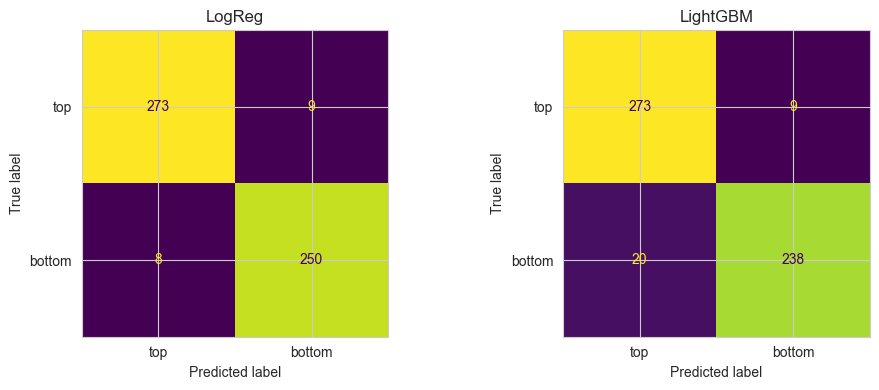

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, pred) in zip(axes, [("LogReg", lr_oof_pred), ("LightGBM", gb_oof_pred)]):
    cm = confusion_matrix(y_train, pred)
    ConfusionMatrixDisplay(cm, display_labels=["top", "bottom"]).plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout(); plt.show()


## Fit best model on all training data, predict everything

We'll pick the higher-AUC model and refit on all confident labels.


In [9]:
lr_auc = roc_auc_score(y_train, lr_oof_proba)
gb_auc = roc_auc_score(y_train, gb_oof_proba)
print(f"LogReg AUC={lr_auc:.3f}, LightGBM AUC={gb_auc:.3f}")
best_pipe = gb_pipe if gb_auc >= lr_auc else lr_pipe
best_name = "LightGBM" if gb_auc >= lr_auc else "LogReg"
print("Picked:", best_name)

best_pipe.fit(train, y_train, clf__sample_weight=train.sample_weight.values)
proba = best_pipe.predict_proba(to_predict)[:, 1]
pred = np.where(proba >= 0.5, "bottom", "top")

to_predict["funnel_pred"] = pred
to_predict["funnel_pred_proba_bottom"] = proba
to_predict["funnel_pred_confidence"] = np.where(
    (proba >= 0.8) | (proba <= 0.2), "high",
    np.where((proba >= 0.65) | (proba <= 0.35), "medium", "low"),
)
print(to_predict.funnel_pred.value_counts())
print(to_predict.funnel_pred_confidence.value_counts())


LogReg AUC=0.994, LightGBM AUC=0.985
Picked: LogReg
top       321
bottom    316
Name: funnel_pred, dtype: int64
high      588
medium     30
low        19
Name: funnel_pred_confidence, dtype: int64


## Sanity check: model predictions vs Stage A labels

In [10]:
# On training rows the model should mostly agree with Stage A
overlap = to_predict[to_predict.funnel_label.notna()]
agree = (overlap.funnel_pred == overlap.funnel_label).mean()
print(f"Agreement with Stage A (where Stage A has a label, any confidence): {agree:.1%}")
print()
print("Disagreement breakdown by Stage A confidence:")
print(overlap.assign(agree=overlap.funnel_pred == overlap.funnel_label)
      .groupby("confidence").agree.agg(["mean", "count"]))


Agreement with Stage A (where Stage A has a label, any confidence): 97.6%

Disagreement breakdown by Stage A confidence:
                mean  count
confidence                 
high        1.000000    338
low         0.863636     44
medium      0.960396    202


## Feature importance / coefficients

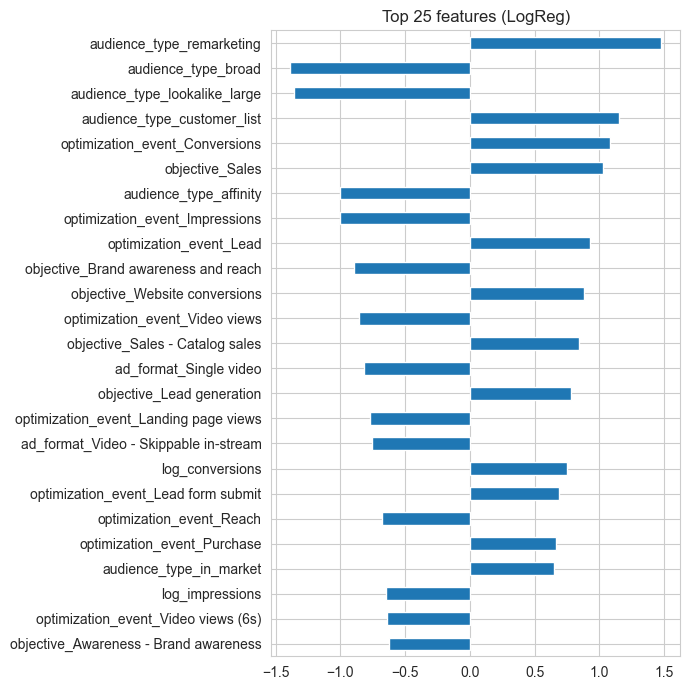

audience_type_remarketing                1.480204
audience_type_broad                     -1.388827
audience_type_lookalike_large           -1.353550
audience_type_customer_list              1.148710
optimization_event_Conversions           1.083883
objective_Sales                          1.028228
audience_type_affinity                  -1.004719
optimization_event_Impressions          -1.000394
optimization_event_Lead                  0.927016
objective_Brand awareness and reach     -0.895357
objective_Website conversions            0.884390
optimization_event_Video views          -0.851967
objective_Sales - Catalog sales          0.842949
ad_format_Single video                  -0.814172
objective_Lead generation                0.781437
optimization_event_Landing page views   -0.770820
ad_format_Video - Skippable in-stream   -0.752855
log_conversions                          0.748007
optimization_event_Lead form submit      0.692407
optimization_event_Reach                -0.681444


In [11]:
if best_name == "LightGBM":
    feat_names = (
        list(NUMERIC) +
        list(best_pipe.named_steps["pre"].named_transformers_["cat"].get_feature_names_out(CATEGORICAL)) +
        list(best_pipe.named_steps["pre"].named_transformers_["txt"].get_feature_names_out())
    )
    imp = best_pipe.named_steps["clf"].feature_importances_
    fi = pd.Series(imp, index=feat_names).sort_values(ascending=False).head(25)
else:
    feat_names = (
        list(NUMERIC) +
        list(best_pipe.named_steps["pre"].named_transformers_["cat"].get_feature_names_out(CATEGORICAL)) +
        list(best_pipe.named_steps["pre"].named_transformers_["txt"].get_feature_names_out())
    )
    coefs = best_pipe.named_steps["clf"].coef_[0]
    fi = pd.Series(coefs, index=feat_names).sort_values(key=abs, ascending=False).head(25)

fig, ax = plt.subplots(figsize=(7, 7))
fi[::-1].plot(kind="barh", ax=ax)
ax.set_title(f"Top 25 features ({best_name})")
plt.tight_layout(); plt.show()
print(fi)


## Save final labeled dataset

In [12]:
final = to_predict[[
    "campaign_id", "customer_id", "platform", "campaign_name",
    "funnel_pred", "funnel_pred_proba_bottom", "funnel_pred_confidence",
    "funnel_label", "confidence",   # original Stage A label + tier
]].rename(columns={
    "funnel_pred": "funnel_level",
    "funnel_pred_proba_bottom": "p_bottom",
    "funnel_pred_confidence": "model_confidence",
    "funnel_label": "stage_a_label",
    "confidence": "stage_a_confidence",
})
final.to_csv("campaigns_labeled.csv", index=False)
print("Saved campaigns_labeled.csv —", len(final), "campaigns")
print()
print(final.funnel_level.value_counts())
print()
print("model confidence distribution:")
print(final.model_confidence.value_counts())


Saved campaigns_labeled.csv — 637 campaigns

top       321
bottom    316
Name: funnel_level, dtype: int64

model confidence distribution:
high      588
medium     30
low        19
Name: model_confidence, dtype: int64


## Reflections (answering the assignment questions)

### How much could Stage A label, and how confident are you?
See coverage printout in notebook 02. The pairwise signal-agreement heatmap is the
direct evidence: where two independent signals agree on most campaigns, the
heuristic is well-calibrated.

### How does the model perform on campaigns Stage A could not label?
We can't measure this directly without ground truth. Three things give indirect signal:
1. **GroupKFold CV** held out *entire customers* — so the AUC above is a fair
   estimate of generalisation across clients.
2. **Agreement with Stage A** on labeled rows (printed above) shows the model
   does not drift away from the heuristics.
3. **Model confidence tier** flags rows where the predicted probability is
   close to 0.5 — these are the campaigns where Stage A also tended to be
   ambiguous, and they should be reviewed manually before being trusted.

Recommended next step: hand-label ~30–50 of the lowest-confidence model predictions
and compare to the model — that gives the only honest answer to the question.
